In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_csv('placement_predict_50k Dataset.csv')

# Remove unnecessary column
df = df.drop(columns=['IsAnomaly'])

In [ ]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
y = df['PlacementStatus']
X = df.drop(columns=['PlacementStatus'])

# Encode ALL categorical columns
X = pd.get_dummies(X, drop_first=True)

# Convert target into numerical values if necessary
if y.dtype == 'object':
    y = y.map({'Not Placed': 0, 'Placed': 1})

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

Accuracy: 0.9982154445165476
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2137
         1.0       1.00      1.00      1.00      4027

    accuracy                           1.00      6164
   macro avg       1.00      1.00      1.00      6164
weighted avg       1.00      1.00      1.00      6164

Saved tree image.


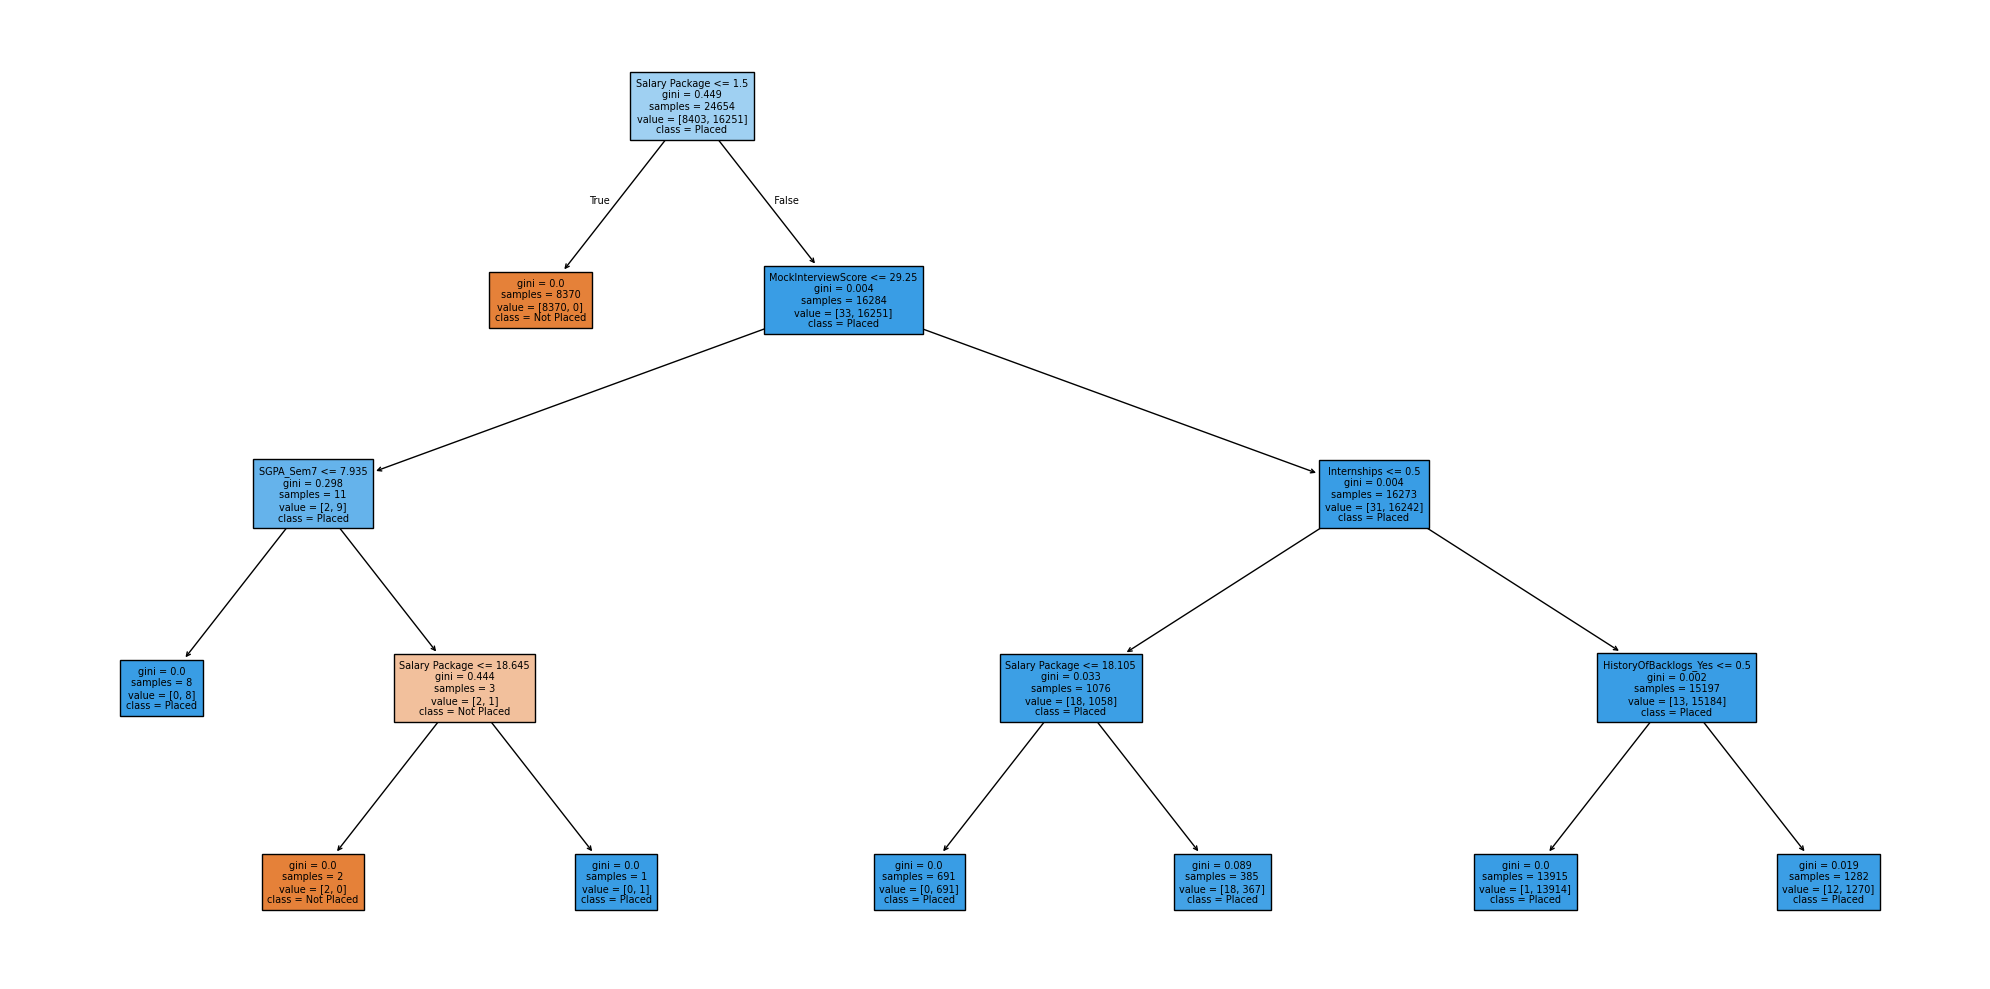

In [ ]:
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Display Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)

print("Saved tree image.")

Random Forest Example

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("placement_predict_50k Dataset.csv")

# Display dataset
print("Sample of the dataset:")
print(df.head())

print(f"\nDataset shape: {df.shape}")


Sample of the dataset:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4 

In [ ]:
TARGET = "Salary Package"

# Remove unnecessary ID column
DROP_COLS = ["StudentID"]

# Separate input and output
X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

# Encode all categorical columns
X = pd.get_dummies(X, drop_first=True)

# Convert target to numerical values if needed
if y.dtype == 'object':
    y = y.map({'Not Placed': 0, 'Placed': 1})

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

print(f"\nOOB Score: {rf.oob_score_:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}")

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

print("\nRegression Report:")
# No direct 'regression_report' function like classification_report, print individual metrics

# Feature importance
print("\nFeature Importances:")

for name, importance in sorted(
    zip(X.columns, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"{name}: {importance:.4f}")


OOB Score: 0.9886
R-squared (R2 Score): 0.9889
Mean Absolute Error (MAE): 0.5336
Mean Squared Error (MSE): 0.8668

Regression Report:

Feature Importances:
CGPA: 0.1373
SGPA_Sem8: 0.1104
SGPA_Sem4: 0.0920
SGPA_Sem5: 0.0845
SGPA_Sem3: 0.0793
SGPA_Sem1: 0.0777
PlacementStatus: 0.0776
SGPA_Sem7: 0.0709
SGPA_Sem6: 0.0656
SGPA_Sem2: 0.0356
CGPA_Tier_Mid: 0.0302
CGPA_Tier_Low: 0.0241
CodingTestScore: 0.0225
SoftSkillsRating: 0.0209
MockInterviewScore: 0.0152
ExtraCurricular: 0.0127
Certifications: 0.0075
AptitudeTestScore: 0.0067
Projects: 0.0060
Workshops: 0.0056
CollegeTier_Tier3: 0.0036
Publications: 0.0029
Internships: 0.0027
AttendancePercent: 0.0026
HistoryOfBacklogs_Yes: 0.0019
IsAnomaly: 0.0007
CollegeTier_Tier2: 0.0003
Hostel_Yes: 0.0002
Gender_Male: 0.0002
Specialisation_Embedded: 0.0002
Specialisation_Networking: 0.0002
Specialisation_DataScience: 0.0002
Stream_ECE: 0.0002
City_Hyderabad: 0.0002
Stream_Mechanical: 0.0002
City_Bangalore: 0.0002
Stream_IT: 0.0002
City_Pune: 0.0001
